# Exam Project - Introduction to Social Data Science
August 28, 2024

## Project: Forecasting Vote Counts for Danish Borgerforslag

## Group 7:
- Oliver Nyrop Weeks (vsn684)
- Sofus Galavits Møller (qvc730)
- Victor V. Kristensen (gcp458)
- Jonas T. Schmidt (mcp656)

## Load modules

In [1]:
# Module Imports
import pandas as pd            # For data manipulation and analysis
from bs4 import BeautifulSoup  # For parsing HTML content
import time                    # For managing time delays during scraping
import tqdm                    # For displaying progress bars during scraping
import pprint                  # For neatly displaying JSON cod
import re                      # For pattern recognition in extracted HTML
import os                      # For interacting with the operating system (e.g., file paths, environment variables)

import matplotlib.pyplot as plt
import seaborn as sns

output_dir = "Output"

## Check dataset

In [2]:
# Load the dataset from the CSV file
loaded_df = pd.read_csv("data/df_after_categorization.csv")

# Display the first few rows of the loaded DataFrame
loaded_df

,Title,Start Date,Votes,Body Text,Num Coauthors,Lifetime,Month_2,Month_3,Month_4,Month_5,...,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10
0,Afskaf inklusionsloven,2024-08-15,39,For at forbedre undervisningen og sikre optima...,3,3,False,False,False,False,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,Fartbøder forhindrer i at opnå Dansk statsborg...,2024-08-06,82,Forslaget drejer sig om regler for fartbøder v...,3,12,False,False,False,False,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,Forbyd dressurridning som konkurrencesport,2024-08-06,245,Dressurridning som konkurrencesport er en spor...,3,12,False,False,False,False,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Lavere skat og fjernelse af minimumsalder på p...,2024-08-06,338,Vi stiller et forslag om ændring af reglerne f...,3,12,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,Bloddonorpligt. Som værnepligt,2024-07-26,41,Jeg forslår at der etableres en pligt til at a...,3,23,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1842,Opæhvelse af begrænsning på 45 knallerter,2018-01-30,189,Jeg stiller hermed forslag om at ophævelsen af...,3,180,False,False,False,False,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1843,Automatisk førtidspension til personer der har...,2018-01-30,66,Forslaget er at man automatisk giver førtidspe...,4,180,False,False,False,False,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1844,POLITISK FORSLAG TIL HØRING I FOLKETINGET OM Æ...,2018-01-30,597,"Lovforslaget går i sin enkelhed ud på, at sikr...",3,180,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1845,"Statsborgerskab til unge mennesker, som er fød...",2018-01-30,6263,Folketinget pålægger regeringen at genindføre ...,3,180,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## Key exploratory numbers:

### First proposal

In [3]:
earliest_start_date = loaded_df['Start Date'].min()

# Display the earliest "Start Date"
print(f"The earliest Start Date is: {earliest_start_date}")

The earliest Start Date is: 2018-01-26


In [4]:
latest_start_date = loaded_df['Start Date'].max()

# Display the earliest "Start Date"
print(f"The earliest Start Date is: {latest_start_date}")

The earliest Start Date is: 2024-08-15


### Number of iniative swith over 50,000 votes

In [5]:
# Filter the DataFrame to get only those rows where the vote count is greater than 50,000
votes_over_50000 = loaded_df[loaded_df['Votes'] > 50000]

# Count the number of such rows
num_initiatives_over_50000 = votes_over_50000.shape[0]

print(f"Number of initiatives with votes over 50,000: {num_initiatives_over_50000}")

Number of initiatives with votes over 50,000: 52


In [6]:
earliest_start_date = loaded_df['Start Date'].min()

# Display the earliest "Start Date"
print(f"The earliest Start Date is: {earliest_start_date}")

The earliest Start Date is: 2018-01-26


### Max Signatures

In [7]:
max_votes = loaded_df['Votes'].max()
print(max_votes)

93227


## Summary Statistics

Summary statistics for the numeric variables:

In [8]:
import os
import pandas as pd

# Assuming 'loaded_df' is your DataFrame

# Make a copy of the original DataFrame to preserve the original data
df_copy = loaded_df.copy()

# Convert the "Big city" boolean column to 0-1 values in the copy
df_copy['Big city'] = df_copy['Big city'].astype(int)

# Convert the "Title All Uppercase" boolean column to 0-1 values in the copy
df_copy['Title All Uppercase'] = df_copy['Title All Uppercase'].astype(int)

# Create a new column 'Sentiment' with values -1 (negative), 0 (neutral), and 1 (positive)
#df_copy['Sentiment'] = df_copy.apply(
#    lambda row: 1 if row['Sentiment_positive'] else (0 if row['Sentiment_neutral'] else -1), axis=1
#)

# Identify the month dummy columns (e.g., 'Month_2', 'Month_3', ..., 'Month_12')
month_columns = [col for col in df_copy.columns if col.startswith('Month_')]

# Create a new column 'Month' with values ranging from 1 to 12 in the copy
# Assuming only one month dummy is True for each row
df_copy['Month'] = df_copy[month_columns].idxmax(axis=1).apply(lambda x: int(x.split('_')[1]))

# Handle the case where 'Month_1' should be 1 when all other months are False
df_copy['Month'] = df_copy.apply(
    lambda row: 1 if row[month_columns].sum() == 0 else row['Month'],
    axis=1
)

# Drop the original month dummy columns in the copy
df_copy.drop(columns=month_columns, inplace=True)

# Now proceed with the rest of the code using df_copy

# Simple descriptions for each variable, with the unit where applicable
variable_descriptions = {
    'Votes': r'Signatures \\ \hspace{1cm}(Amount)',
    'Num Coauthors': r'Num. Co-proposers\\ \hspace{1cm}(Amount)',
    'Lifetime': r'Lifetime \\ \hspace{1cm}(Days)',
    'Month': r'Start Month \\ \hspace{1cm}(Month 1-12)',
    'Title Length': r'Title Length \\ \hspace{1cm}(Characters)',
    'Body Text Length': r'Body Text Length \\ \hspace{1cm}(Characters)',
    'Title Uppercase Count': r'Title Uppercase Count \\ \hspace{1cm}(Count)',
    'Body Text Uppercase Count': r'Body Text Uppercase Count \\ \hspace{1cm}(Count)',
    'Title Lowercase Count': r'Title Lowercase Count \\ \hspace{1cm}(Count)',
    'Body Text Lowercase Count': r'Body Text Lowercase Count \\ \hspace{1cm}(Count)',
    'Body Text LIX Score': r'Body Text LIX Score \\ \hspace{1cm}(Score)',
    'Distance to parliament km': r'Distance to parliament \\ \hspace{1cm}(km)',
    'Big city': r'Big city \\ \hspace{1cm}(No=0,Yes=1)',
    'Title All Uppercase': r'Title All Uppercase \\ \hspace{1cm}(No=0,Yes=1)'
    #,'Sentiment': r'Sentiment \\ \hspace{1cm}(-1 to 1)'
}

# Function to encapsulate each description in the LaTeX tabular format
def format_variable_description(description):
    return r'\begin{tabular}{@{}l@{}} ' + description + r' \end{tabular}'

# Apply the formatting function to each entry in the dictionary
formatted_variable_descriptions = {key: format_variable_description(value) for key, value in variable_descriptions.items()}

# Filter out the 'topic' columns from the copied DataFrame
non_topic_columns = [col for col in df_copy.columns if not col.startswith('topic')]
filtered_df = df_copy[non_topic_columns]

# Get the summary statistics for the filtered DataFrame and transpose the table
summary_statistics = filtered_df.describe().transpose()

# Reorder the DataFrame rows to place Title-related rows first and then Body Text-related rows
order = [
    'Votes',
    'Days from start to scrape', 'Days from start to end','Lifetime', 'Month', 
    'Num Coauthors',
    'Title Length', 'Title Uppercase Count', 'Title Lowercase Count', 'Title All Uppercase',
    'Body Text Length', 'Body Text Uppercase Count', 'Body Text Lowercase Count', 'Body Text LIX Score',
    'Distance to parliament km', 'Big city',
]

summary_statistics = summary_statistics.loc[[col for col in order if col in summary_statistics.index]]

# Replace index labels with formatted descriptions
summary_statistics.index = summary_statistics.index.map(lambda x: formatted_variable_descriptions.get(x, x))

# Capitalize the first letter of each statistic name
summary_statistics.columns = summary_statistics.columns.str.capitalize()

# Convert the summary statistics to a LaTeX table with formatting and escape special characters
latex_table = summary_statistics.to_latex(
    index=True,                # Include the row names (e.g., variable names)
    float_format="%.1f",       # Format the floating-point numbers to 1 decimal place
    caption="Summary Statistics for Numeric Variables",  # Add a caption for the table
    label="tab:summary",       # Add a label for referencing in LaTeX
    escape=False               # Do not escape special characters to allow LaTeX formatting
)
print(latex_table)

# Define the output file path
output_file_path = os.path.join(output_dir, "summary_table.tex")

# Write the LaTeX table to a file
with open(output_file_path, "w") as file:
    file.write(latex_table)

# Confirm the file was created
print(f"LaTeX table saved to: {output_file_path}")


\begin{table}
\caption{Summary Statistics for Numeric Variables}
\label{tab:summary}
\begin{tabular}{lrrrrrrrr}
\toprule
 & Count & Mean & Std & Min & 25% & 50% & 75% & Max \\
\midrule
\begin{tabular}{@{}l@{}} Signatures \\ \hspace{1cm}(Amount) \end{tabular} & 1847.0 & 3248.8 & 10376.9 & 6.0 & 102.0 & 282.0 & 1150.0 & 93227.0 \\
\begin{tabular}{@{}l@{}} Lifetime \\ \hspace{1cm}(Days) \end{tabular} & 1847.0 & 178.2 & 41.4 & 3.0 & 180.0 & 180.0 & 180.0 & 1202.0 \\
\begin{tabular}{@{}l@{}} Start Month \\ \hspace{1cm}(Month 1-12) \end{tabular} & 1847.0 & 5.7 & 3.4 & 1.0 & 3.0 & 5.0 & 8.5 & 12.0 \\
\begin{tabular}{@{}l@{}} Num. Co-proposers\\ \hspace{1cm}(Amount) \end{tabular} & 1847.0 & 4.0 & 1.8 & 3.0 & 3.0 & 3.0 & 4.0 & 10.0 \\
\begin{tabular}{@{}l@{}} Title Length \\ \hspace{1cm}(Characters) \end{tabular} & 1847.0 & 59.1 & 32.7 & 7.0 & 35.0 & 50.0 & 76.0 & 141.0 \\
\begin{tabular}{@{}l@{}} Title Uppercase Count \\ \hspace{1cm}(Count) \end{tabular} & 1847.0 & 2.6 & 6.9 & 0.0 & 1.0 & 1.0 

## Summary statistics for votes

In [9]:
import os
import pandas as pd

# Extract the summary statistics specifically for the 'Votes' variable
votes_summary = filtered_df['Votes'].describe().to_frame().transpose()

# Replace the index label with the desired name "Votes (Amount)"
votes_summary.index = ["Votes (Amount)"]

# Capitalize the first letter of each statistic name
votes_summary.columns = votes_summary.columns.str.capitalize()

# Convert the summary statistics for 'Votes' to a LaTeX table with formatting and escape special characters
latex_votes_table = votes_summary.to_latex(
    index=True,                # Include the row name (i.e., the variable name)
    float_format="%.1f",       # Format the floating-point numbers to 1 decimal place
    caption="Summary Statistics for Votes",  # Add a caption specifically for the 'Votes' variable
    label="tab:votes_summary", # Add a label for referencing in LaTeX
    escape=False               # Do not escape special characters to allow LaTeX formatting
)

print(latex_votes_table)

# Define the output file path specifically for the 'Votes' summary table
output_file_path_votes = os.path.join(output_dir, "votes_summary_table.tex")

# Write the LaTeX table for 'Votes' to a file
with open(output_file_path_votes, "w") as file:
    file.write(latex_votes_table)

# Confirm the file was created
print(f"LaTeX table for 'Votes' saved to: {output_file_path_votes}")


\begin{table}
\caption{Summary Statistics for Votes}
\label{tab:votes_summary}
\begin{tabular}{lrrrrrrrr}
\toprule
 & Count & Mean & Std & Min & 25% & 50% & 75% & Max \\
\midrule
Votes (Amount) & 1847.0 & 3248.8 & 10376.9 & 6.0 & 102.0 & 282.0 & 1150.0 & 93227.0 \\
\bottomrule
\end{tabular}
\end{table}

LaTeX table for 'Votes' saved to: Output/votes_summary_table.tex


## Time investigation

Run this code if Lifetime has not been dropped:
```python
# Create a figure with two subplots side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=False)

# Plot the full distribution histogram in the left subplot
ax1.hist(loaded_df['Lifetime'], bins=30, edgecolor='black')
ax1.set_title('A) Distribution of Lifetime')
ax1.set_xlabel('Lifetime')
ax1.set_ylabel('Frequency')
ax1.set_ylim(0, 1750)  # Set the y-axis range for the full distribution

# Plot the zoomed-in distribution histogram in the right subplot
ax2.hist(loaded_df['Lifetime'], bins=30, edgecolor='black')
ax2.set_title('B) Distribution of Lifetime (Y-axis Zoomed x20)')
ax2.set_xlabel('Lifetime')
ax2.set_ylim(0, 175/2)  # Set the y-axis range for the zoomed-in distribution

# Adjust the layout to prevent overlapping
plt.tight_layout()

# Save the figure as a PDF
output_path = os.path.join(output_dir, "Lifetime_plot.pdf")
fig.savefig(output_path)

# Show the plots
plt.show()
```

Now find max value of lifetime:

In [10]:
#max_lifetime = loaded_df['Lifetime'].max()
#max_lifetime

## Seasonal

/var/folders/s3/s58q439926xb4bq1gzzpvw0r0000gn/T/ipykernel_73858/1478123429.py:32: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  months = pd.date_range('2023-01-01', periods=12, freq='M').strftime('%B')


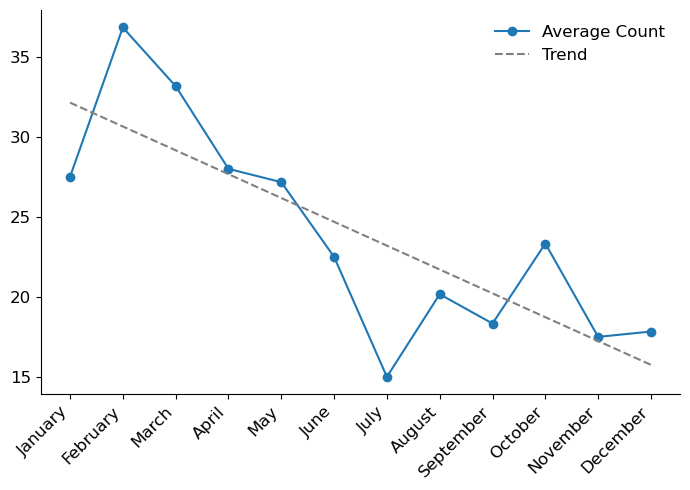

Image saved to: Output/season_plot.pdf


In [11]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress

# Assuming loaded_df is already provided

# Copy the original DataFrame to avoid overwriting
loaded_df2 = loaded_df.copy()

# Ensure 'Start Date' is in datetime format
loaded_df2['Start Date'] = pd.to_datetime(loaded_df2['Start Date'], errors='coerce')

# Extract the month (ignoring the year) and year
loaded_df2['Month'] = loaded_df2['Start Date'].dt.month
loaded_df2['Year'] = loaded_df2['Start Date'].dt.year

# Remove all observations from 2024
loaded_df2 = loaded_df2[loaded_df2['Year'] != 2024]

# Count occurrences by month (aggregated across all years)
monthly_counts = loaded_df2['Month'].value_counts().sort_index()

# Calculate the number of years with data for each month
years_per_month = loaded_df2.groupby('Month')['Year'].nunique()

# Calculate the average number of observations per month
monthly_avg_counts = monthly_counts / years_per_month

# Map month numbers to month names
months = pd.date_range('2023-01-01', periods=12, freq='M').strftime('%B')

# Create the plot with specified figure size
fig, ax = plt.subplots(figsize=(7, 5))

# Plot the average count per month
ax.plot(monthly_avg_counts.index, monthly_avg_counts.values, marker='o', label='Average Count')

# Perform linear regression to add a trend line
slope, intercept, r_value, p_value, std_err = linregress(monthly_avg_counts.index, monthly_avg_counts.values)
trendline = slope * monthly_avg_counts.index + intercept
ax.plot(monthly_avg_counts.index, trendline, color='grey', linestyle='--', label='Trend')

# Set the labels and title with increased font size
#ax.set_ylabel('Average Count per Month', fontsize=12)
#ax.set_title('Average Count per Month (Excluding 2024 Data)', fontsize=14)

# Set the x-ticks to display month names with increased font size
ax.set_xticks(monthly_avg_counts.index)
ax.set_xticklabels(months, rotation=45, ha='right', fontsize=12)

# Increase y-tick label size
ax.tick_params(axis='y', labelsize=12)

# Remove the right and left spines (borders)
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

# Add a legend without a box around it and move it slightly down in the right
ax.legend(frameon=False, loc='upper right', fontsize=12)

# Adjust layout to make room for the x-axis labels
plt.tight_layout()

# Define the output directory and file path
output_file_path = os.path.join(output_dir, "season_plot.pdf")

# Save the plot to the specified file path with bbox_inches to ensure all elements are included
plt.savefig(output_file_path, bbox_inches='tight')

# Show the plot
plt.show()

# Confirm the file was created
print(f"Image saved to: {output_file_path}")


# Number of Co-Authors

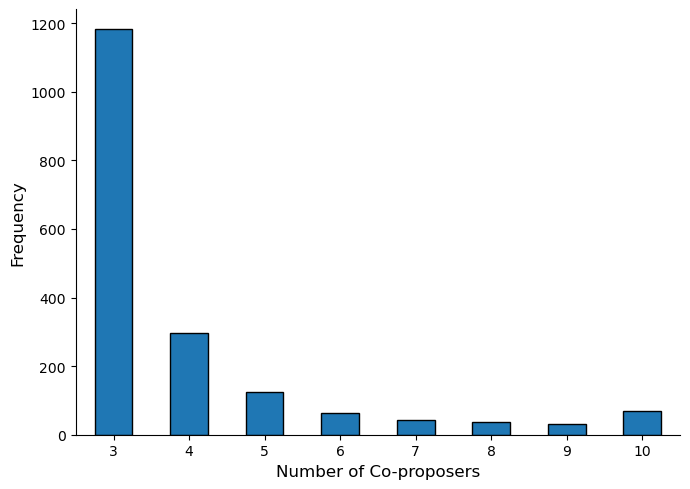

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Assuming loaded_df is already available as a pandas DataFrame
# If loaded_df is not yet defined, you would load your dataset first, for example:
# loaded_df = pd.read_csv('your_dataset.csv')

# Create a new dataset based on loaded_df
new_df = loaded_df.copy()

# Generate a bar plot for the variable "Num Coauthors"
plt.figure(figsize=(7, 5))
new_df['Num Coauthors'].value_counts().sort_index().plot(kind='bar', edgecolor='black')

# Increase font size to 12 for labels
plt.xlabel('Number of Co-proposers', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Rotate x-axis labels 90 degrees clockwise
plt.xticks(rotation=0)

# Remove grid lines
plt.grid(False)

# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust layout to prevent clipping
plt.tight_layout()

# Save the plot as a PDF
output_path = os.path.join(output_dir, "num_coauthors_plot.pdf")
plt.savefig(output_path)

plt.show()


## Text analysis

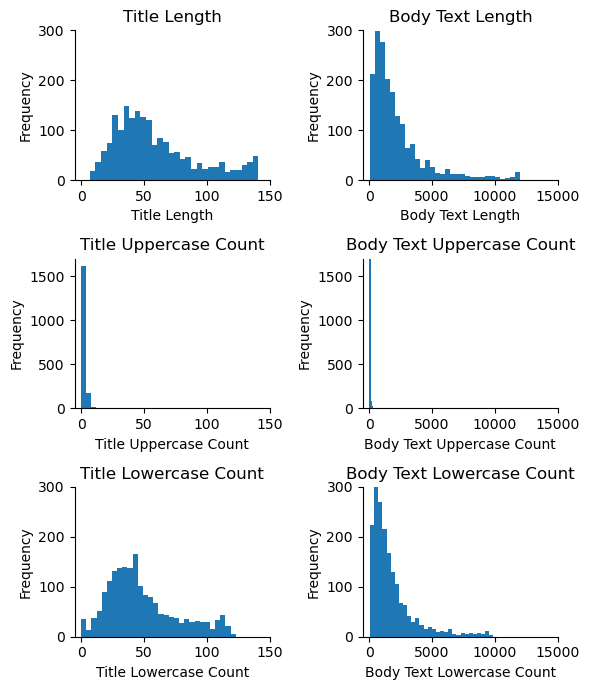

Title All Uppercase - True count: 35
Title All Uppercase - False count: 1812


In [13]:
import matplotlib.pyplot as plt
import os

# List of variables to plot in the new order, excluding the boolean variable
variables = [
    "Title Length",
    "Body Text Length",
    "Title Uppercase Count",
    "Body Text Uppercase Count",
    "Title Lowercase Count",
    "Body Text Lowercase Count"
]

# Convert the boolean variable "Title All Uppercase" to 0 and 1 values
loaded_df["Title All Uppercase"] = loaded_df["Title All Uppercase"].astype(int)

# Determine the number of subplots (3 rows, 2 columns) to accommodate the variables
fig, axes = plt.subplots(3, 2, figsize=(6, 7))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plot histograms for each variable in a subplot
for i, var in enumerate(variables):
    axes[i].hist(loaded_df[var], bins=30)
    axes[i].set_title(f'{var}')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Frequency')
    
    # Set y-axis limits based on the row
    if i // 2 == 0:  # First row (0, 1 indices)
        axes[i].set_ylim(0, 300)
    elif i // 2 == 1:  # Second row (2, 3 indices)
        axes[i].set_ylim(0, 1700)
    elif i // 2 == 2:  # Third row (4, 5 indices)
        axes[i].set_ylim(0, 300)
    
    # Set x-axis limits based on the column
    if i % 2 == 0:  # Left column (0, 2, 4 indices)
        axes[i].set_xlim(-5, 150)
    else:  # Right column (1, 3, 5 indices)
        axes[i].set_xlim(-500, 15000)
    
    # Remove the right and top spines
    axes[i].spines['right'].set_visible(False)
    axes[i].spines['top'].set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()

# Output
output_path = os.path.join(output_dir, "text_plot.pdf")
fig.savefig(output_path)

# Show
plt.show()

# Calculate and output the count of True and False values for the boolean variable
true_count = loaded_df["Title All Uppercase"].sum()
false_count = len(loaded_df) - true_count

print(f"Title All Uppercase - True count: {true_count}")
print(f"Title All Uppercase - False count: {false_count}")


## LIX

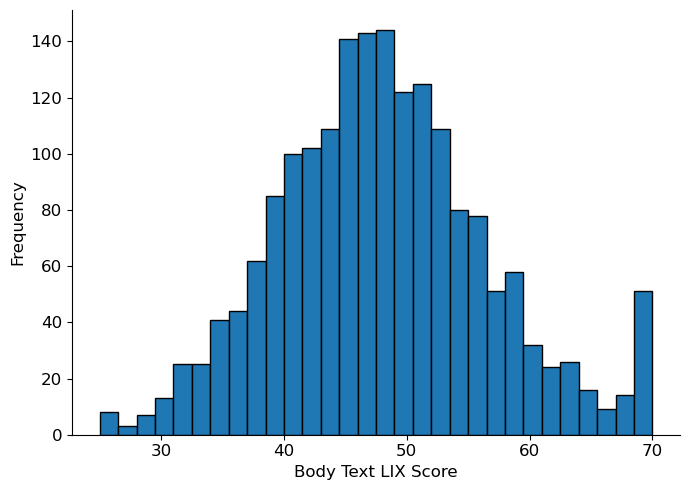

The interval with the most observations is: (47.5, 49.0)


In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'loaded_df' is already defined and contains the data
# Creating a new dataset with only the "Body Text LIX Score" column
new_df = loaded_df[['Body Text LIX Score']].copy()

# Plotting the distribution of the "Body Text LIX Score" variable and capturing histogram data
plt.figure(figsize=(7, 5))
counts, bin_edges, _ = plt.hist(new_df['Body Text LIX Score'], bins=30, edgecolor='black')
plt.xlabel('Body Text LIX Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Increase font size for tick labels
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Remove grid lines
plt.grid(False)

# Remove top and right spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Adjust layout to prevent overlap
plt.tight_layout()

# Output
output_path = os.path.join(output_dir, "lix_plot.pdf")
plt.savefig(output_path)

# Show
plt.show()

# Identifying the interval with the most observations
max_count_index = counts.argmax()
most_frequent_interval = (bin_edges[max_count_index], bin_edges[max_count_index + 1])

print(f"The interval with the most observations is: {most_frequent_interval}")


# Geographics

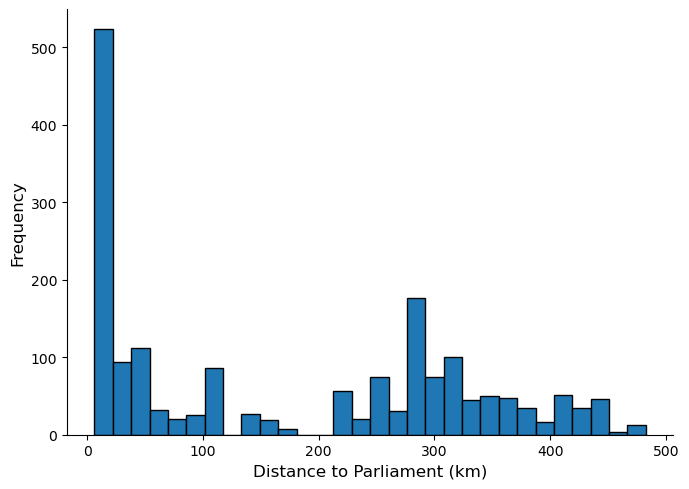

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Assuming loaded_df is already available as a pandas DataFrame
# If loaded_df is not yet defined, you would load your dataset first, for example:
# loaded_df = pd.read_csv('your_dataset.csv')

# Create a new dataset based on loaded_df
new_df = loaded_df.copy()

# Generate a histogram over the variable "Distance to parliament km"
plt.figure(figsize=(7, 5))
plt.hist(new_df['Distance to parliament km'], bins=30, edgecolor='black')

# Increase font size to 12 for title, labels, and axes
#plt.title('Distribution of Distance to Parliament (km)', fontsize=12)
plt.xlabel('Distance to Parliament (km)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)

# Remove grid lines
plt.grid(False)

# Remove top and right spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Adjust layout to prevent clipping
plt.tight_layout()

# Save the plot as a PDF
output_path = os.path.join(output_dir, "geo_plot.pdf")
plt.savefig(output_path)

plt.show()


# Sentiments

In [16]:
import pandas as pd

# Assuming 'loaded_df' is already defined and contains the data

# Calculate the counts for each sentiment category
sentiment_counts = pd.DataFrame({
        'Negative': (~(loaded_df['Sentiment_neutral'] | loaded_df['Sentiment_positive'])).sum(),
    'Neutral': loaded_df['Sentiment_neutral'].sum(),
    'Positive': loaded_df['Sentiment_positive'].sum()
}, index=['Count'])

# Convert the DataFrame to a LaTeX table
latex_table = sentiment_counts.to_latex(index=True, caption="Distribution of Sentiment Categories", label="tab:sentiment_distribution")

# Print the LaTeX table
print(latex_table)


\begin{table}
\caption{Distribution of Sentiment Categories}
\label{tab:sentiment_distribution}
\begin{tabular}{lrrr}
\toprule
 & Negative & Neutral & Positive \\
\midrule
Count & 894 & 115 & 838 \\
\bottomrule
\end{tabular}
\end{table}



# Topics

In [17]:
import pandas as pd

# Assuming 'loaded_df' is already defined and contains the data
# Select columns for topics
topic_columns = [f'topic_{i}' for i in range(1, 11)]
topic_distribution = loaded_df[topic_columns].sum()

# Rename the index to be more readable
topic_distribution.index = [f'Topic {i}' for i in range(1, 11)]

# Convert the series to a DataFrame for better formatting
topic_distribution_df = topic_distribution.reset_index()
topic_distribution_df.columns = ['Topic', 'Frequency']

# Ensure frequencies have no decimal numbers (convert to integers)
topic_distribution_df['Frequency'] = topic_distribution_df['Frequency'].astype(int)

# Transpose the DataFrame
transposed_df = topic_distribution_df.set_index('Topic').T

# Generate LaTeX table from the transposed DataFrame
latex_table = transposed_df.to_latex(index=True, caption="Distribution of Topics", label="tab:topic_distribution", float_format="%.0f")

# Print the LaTeX table
print(latex_table)


\begin{table}
\caption{Distribution of Topics}
\label{tab:topic_distribution}
\begin{tabular}{lrrrrrrrrrr}
\toprule
Topic & Topic 1 & Topic 2 & Topic 3 & Topic 4 & Topic 5 & Topic 6 & Topic 7 & Topic 8 & Topic 9 & Topic 10 \\
\midrule
Frequency & 103 & 242 & 264 & 193 & 261 & 228 & 262 & 96 & 286 & 216 \\
\bottomrule
\end{tabular}
\end{table}



# Creating a pairplot over the features in our model

In [18]:
import pandas as pd

# Load the dataset from the CSV file
features_df = pd.read_csv("Data/df_after_categorization.csv")

# Display the first few rows of the loaded DataFrame
features_df.head(5)

,Title,Start Date,Votes,Body Text,Num Coauthors,Lifetime,Month_2,Month_3,Month_4,Month_5,...,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10
0,Afskaf inklusionsloven,2024-08-15,39,For at forbedre undervisningen og sikre optima...,3,3,False,False,False,False,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
1,Fartbøder forhindrer i at opnå Dansk statsborg...,2024-08-06,82,Forslaget drejer sig om regler for fartbøder v...,3,12,False,False,False,False,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,Forbyd dressurridning som konkurrencesport,2024-08-06,245,Dressurridning som konkurrencesport er en spor...,3,12,False,False,False,False,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Lavere skat og fjernelse af minimumsalder på p...,2024-08-06,338,Vi stiller et forslag om ændring af reglerne f...,3,12,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,Bloddonorpligt. Som værnepligt,2024-07-26,41,Jeg forslår at der etableres en pligt til at a...,3,23,False,False,False,False,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


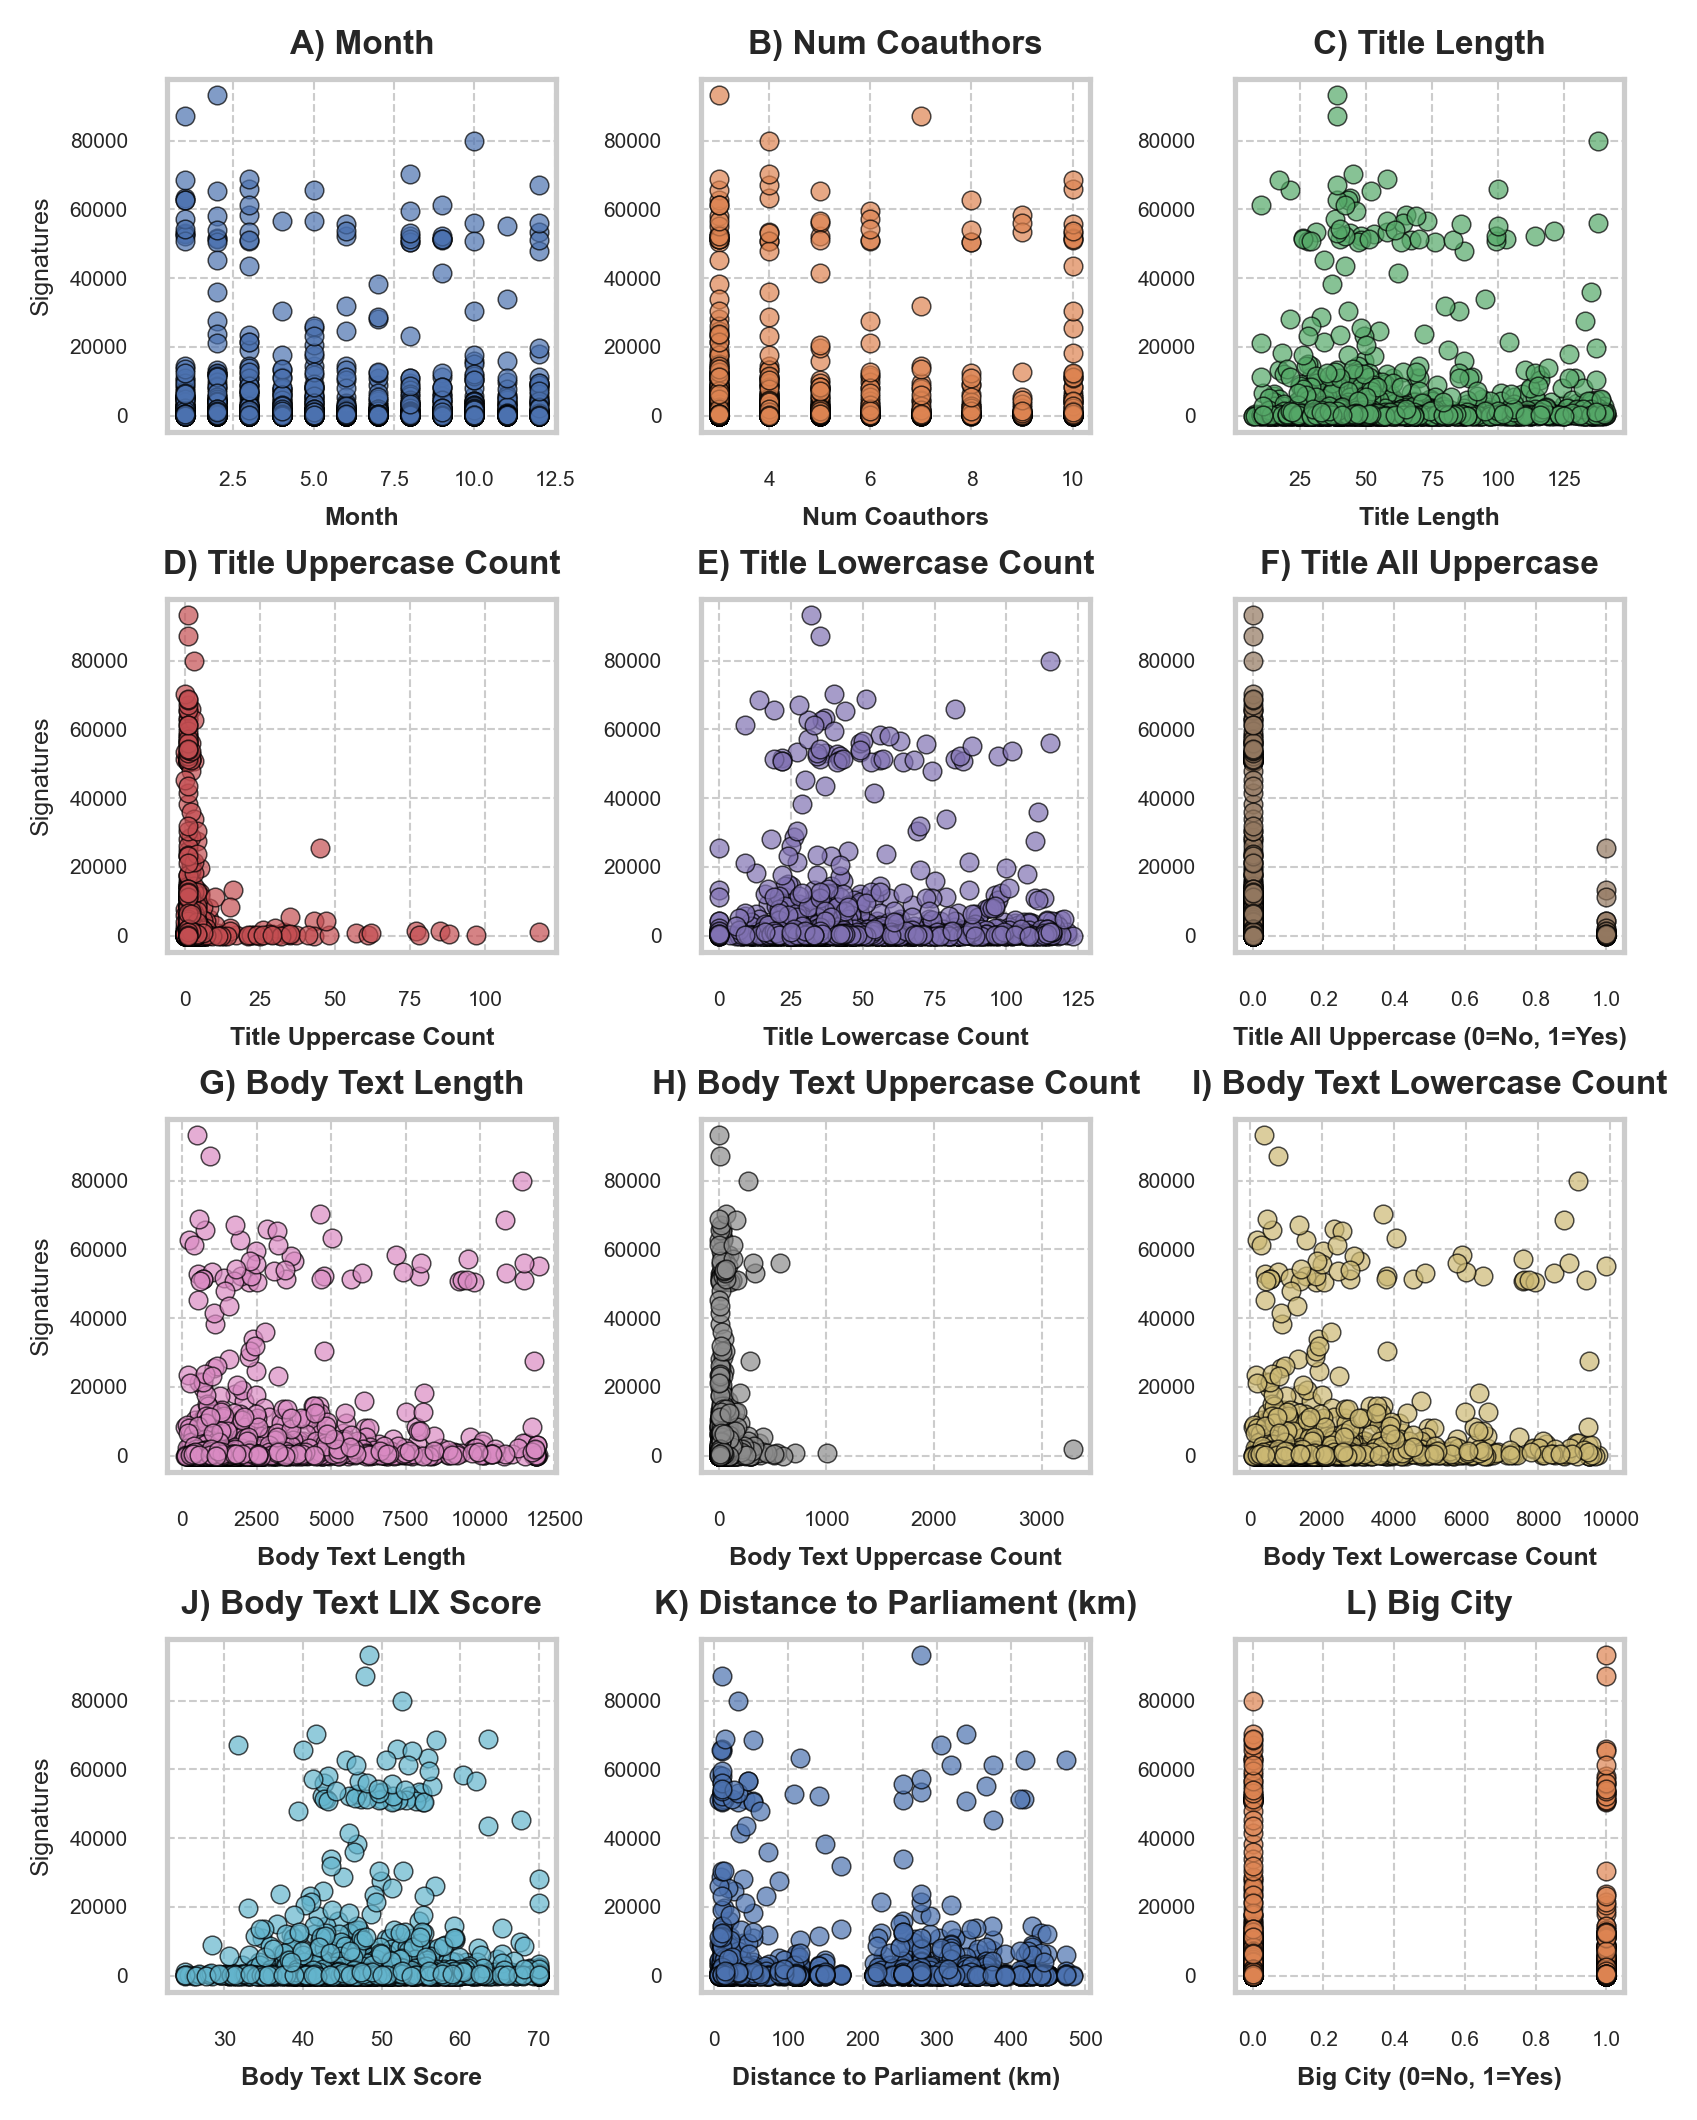

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clear previous figures and reset plotting configurations
plt.close('all')
sns.reset_defaults()

# Reapply Seaborn style settings
sns.set(style="whitegrid")

# Reapply custom matplotlib settings
plt.rc('axes', titlesize=6)
plt.rc('axes', labelsize=6)
plt.rc('xtick', labelsize=5)
plt.rc('ytick', labelsize=5)

# Creating a plot where the number of signatures are plotted against the features in the dataset
y_variable = 'Votes'
x_variables = [ 'Month', 
                'Num Coauthors', 
                'Title Length', 
                'Title Uppercase Count', 
                'Title Lowercase Count', 
                'Title All Uppercase',  # Original name, assuming it's in your dataset
                'Body Text Length', 
                'Body Text Uppercase Count', 
                'Body Text Lowercase Count', 
                'Body Text LIX Score', 
                'Distance to parliament km',  # Original name
                'Big city'  # Original name
                ]

# Mapping of original variable names to display labels
x_labels = {
    'Month': 'Month',
    'Num Coauthors': 'Num Coauthors',
    'Title Length': 'Title Length',
    'Title Uppercase Count': 'Title Uppercase Count',
    'Title Lowercase Count': 'Title Lowercase Count',
    'Body Text Length': 'Body Text Length',
    'Body Text Uppercase Count': 'Body Text Uppercase Count',
    'Body Text Lowercase Count': 'Body Text Lowercase Count',
    'Body Text LIX Score': 'Body Text LIX Score',
    'Distance to parliament km': 'Distance to Parliament (km)',  # New label
    'Big city': 'Big City',  # New label
    'Title All Uppercase': 'Title All Uppercase'  # Assuming you want to display it as is
}

color_palette = sns.color_palette("deep")

fig, axes = plt.subplots(4, 3, figsize=(5.5, 7), dpi=300)

axes = axes.flatten()

# Generate subplot labels A), B), C), etc., with new labels
subplot_labels = [f"{chr(65 + i)}) {x_labels[x_variables[i]]}" for i in range(len(x_variables))]

for i, (x_variable, subplot_label) in enumerate(zip(x_variables, subplot_labels)):
    sns.scatterplot(data=df_copy, x=x_variable, y=y_variable, ax=axes[i], color=color_palette[i % len(color_palette)], s=20, edgecolor='black', alpha=0.7)
    
    # Check if the variable is "Big City" or "Title All Uppercase" and add "(0=No, 1=Yes)" to the label
    if x_variable in ['Big city', 'Title All Uppercase']:
        x_label = f"{x_labels[x_variable]} (0=No, 1=Yes)"
    else:
        x_label = x_labels[x_variable]
    
    # Set the x-axis label with new label in bold
    axes[i].set_xlabel(f"{x_label}", fontsize=6, weight='bold')
    
    # Only set the y-axis label on the first column of plots
    if i % 3 == 0:  # Check if it's the first column
        axes[i].set_ylabel('Signatures')
    else:
        axes[i].set_ylabel('')  # Remove y-axis label for other columns
    
    # Set the plot title as "A) Month", "B) Num Coauthors", etc., with new labels
    axes[i].set_title(f"{subplot_label}", fontsize=8, weight='bold')
    axes[i].grid(True, which='both', linestyle='--', linewidth=0.5)

for i in range(len(x_variables), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout(pad=0.4)

plt.savefig('Output/scatterplot_features_overview.pdf', dpi=300, bbox_inches='tight')

plt.show()


## Test plots

In [20]:
import os
import matplotlib.pyplot as plt

# Assuming 'loaded_df' is your DataFrame containing the 'Votes' column

# Define the output directory and file path
output_file_path = os.path.join(output_dir, "cumulative_histogram_votes.png")

# Create the figure with two subplots
plt.figure(figsize=(10, 10))

# Subplot 1: Full range cumulative histogram
plt.subplot(2, 1, 1)
plt.hist(loaded_df['Votes'], bins=50, cumulative=True, color='mediumseagreen', edgecolor='black', alpha=0.8)
plt.xlabel('Votes', fontsize=14)
plt.ylabel('Cumulative Frequency', fontsize=14)
plt.ylim(0, None)
plt.xticks(fontsize=12, color='darkslategray')
plt.yticks(fontsize=12, color='darkslategray')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().yaxis.grid(True, linestyle='--', alpha=0.7)
plt.title('Cumulative Histogram - Full Range', fontsize=16)

# Subplot 2: Cumulative histogram with x-axis limited to 0-1000
plt.subplot(2, 1, 2)
plt.hist(loaded_df['Votes'], bins=5000, color='mediumseagreen', edgecolor='black', alpha=0.8)
plt.xlabel('Votes', fontsize=14)
plt.ylabel('Cumulative Frequency', fontsize=14)
plt.ylim(0, None)
plt.xlim(0, 1000)  # Set x-axis limit to 0-1000
plt.xticks(fontsize=12, color='darkslategray')
plt.yticks(fontsize=12, color='darkslategray')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().yaxis.grid(True, linestyle='--', alpha=0.7)
plt.title('Cumulative Histogram - X-axis 0-1000', fontsize=16)

# Tight layout for better spacing
plt.tight_layout()

# Save the plot to the specified file path
plt.savefig(output_file_path)

# Confirm the file was created
print(f"Cumulative histogram saved to: {output_file_path}")


Cumulative histogram saved to: Output/cumulative_histogram_votes.png
